# Before We Begin: Understanding the Data
### Temporally Entangled Documents DocEng '26 Tutorial

This is a warm-up, not Block 1. We're not going to build a timeline or measure anything yet. Before we do, it's worth slowing down and asking a more basic question: **what actually is this data, and where does each piece of it come from?**

Every dataset in this tutorial is synthetic, but each one is modeled on a real hospital data source, generated by a real system, a real device, or a real person, on their own schedule. By the end of this notebook you'll have looked at every stream we work with in this tutorial, understood *who or what* generates it and *how*, and seen, with real numbers from our own data, why entanglement isn't an edge case, it's the default state of a modern clinical record.

Nothing here is modeled or aligned. That's Blocks 1 through 3. This is just: **meet the data.**

## Setup

In [49]:
!rm -rf doceng26-pulse-and-paper
!git clone -q https://github.com/lbutler2405/doceng26-pulse-and-paper.git
DATA_DIR = "/content/doceng26-pulse-and-paper/"

import sys
sys.path.insert(0, DATA_DIR)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

TEAL, SEAFOAM, MINT, DARK, MUTED, CORAL, AMBER = (
    "#028090", "#00A896", "#02C39A", "#0A2E36", "#6B7C7E", "#D96C6C", "#E1A82D"
)

patients = pd.read_csv(f"{DATA_DIR}/data/synthetic_patients.csv")
print(f"{len(patients)} patients in this corpus. Let's meet what was collected about them.")

75 patients in this corpus. Let's meet what was collected about them.


## The patient record itself

**Real-world source:** the hospital's Admission-Discharge-Transfer (ADT) system, the registration desk, essentially. This is filled in once, at admission, and barely changes afterward. It's the one part of a chart that behaves like a normal, static database row.

In [50]:
patients.head(8)

,subject_id,hadm_id,stay_id,age,gender,careunit,admittime,dischtime,hospital_complexity_tier,entanglement_tier,population_context,socioeconomic_context,admit_reason,comorbidities,has_cardiac_history
0,90000001,92000001,93000001,35,M,CVICU,2024-09-17 10:43:00,2024-09-18 03:04:00,A_minimal,high,none,standard_resourced,arrhythmia,"heart failure, type 2 diabetes",True
1,90000002,92000002,93000002,50,M,CVICU,2025-09-17 22:20:00,2025-09-21 17:52:00,B_moderate,medium,none,under_resourced,altered mental status,"coronary artery disease, chronic kidney disease",True
2,90000003,92000003,93000003,71,M,CCU,2024-04-01 09:37:00,2024-04-08 21:07:00,C_complex,low,neurodivergent,under_resourced,sepsis workup,"prior myocardial infarction, atrial fibrillation",True
3,90000004,92000004,93000004,73,M,CVICU,2024-04-08 00:26:00,2024-04-11 06:35:00,B_moderate,high,none,standard_resourced,altered mental status,coronary artery disease,True
4,90000005,92000005,93000005,60,M,SICU,2024-11-26 07:25:00,2024-11-29 08:34:00,C_complex,low,dementia_mild,standard_resourced,shortness of breath,prior myocardial infarction,True
5,90000006,92000006,93000006,76,M,MICU,2025-08-20 14:33:00,2025-08-21 12:34:00,A_minimal,high,disability,standard_resourced,arrhythmia,none,False
6,90000007,92000007,93000007,67,F,CVICU,2024-01-16 23:38:00,2024-01-17 17:27:00,A_minimal,high,none,standard_resourced,arrhythmia,COPD,False
7,90000008,92000008,93000008,71,F,SICU,2024-09-10 08:28:00,2024-09-14 16:40:00,C_complex,high,none,standard_resourced,sepsis workup,none,False


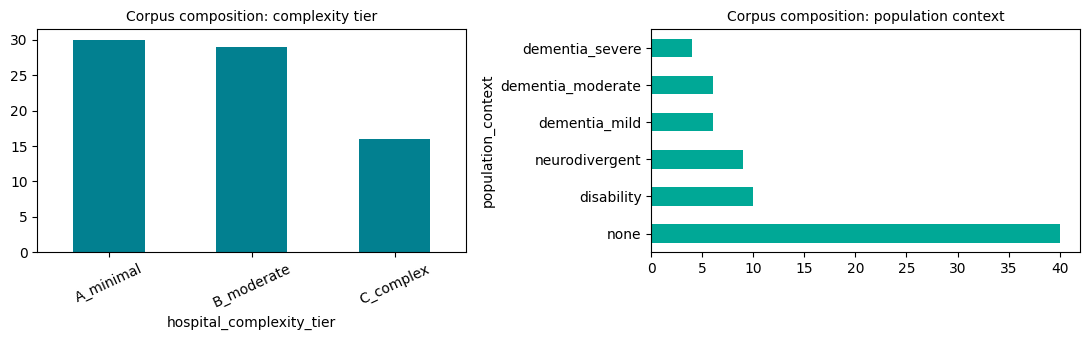

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
patients.hospital_complexity_tier.value_counts().reindex(["A_minimal","B_moderate","C_complex"]).plot(
    kind="bar", ax=axes[0], color=TEAL)
axes[0].set_title("Corpus composition: complexity tier", fontsize=10)
axes[0].tick_params(axis='x', rotation=25)

patients.population_context.value_counts().plot(kind="barh", ax=axes[1], color=SEAFOAM)
axes[1].set_title("Corpus composition: population context", fontsize=10)
fig.tight_layout()
plt.show()

Notice this alone tells you almost nothing about *when* things happened during the stay. That's the point, admission data is stable and well-behaved. Everything else in this notebook is not.

## The continuous stream: vital signs

**Real-world source:** bedside monitors, pulse oximeter, ECG leads, a blood pressure cuff or arterial line, wired directly to the patient. This is the closest thing a hospital has to a true continuous signal, and it's auto-charted to the flowsheet at a fixed interval, no human decides when a heart rate gets recorded.

In [52]:
vitals = pd.read_csv(f"{DATA_DIR}/data/synthetic_vitals_continuous.csv", parse_dates=["charttime"])
vitals.head(8)

,subject_id,stay_id,charttime,heartrate,resprate,o2sat,sbp,dbp,signal_quality
0,90000001,93000001,2024-09-17 11:43:00,80.9,17.3,97.4,119.7,68.6,normal
1,90000001,93000001,2024-09-17 12:43:00,81.8,20.5,97.0,126.2,69.8,normal
2,90000001,93000001,2024-09-17 13:43:00,89.8,23.6,97.6,131.3,61.7,normal
3,90000001,93000001,2024-09-17 14:43:00,88.4,21.6,97.5,134.3,73.2,normal
4,90000001,93000001,2024-09-17 15:43:00,84.5,18.5,97.7,96.1,72.4,normal
5,90000001,93000001,2024-09-17 16:43:00,72.4,20.6,97.8,113.8,64.7,normal
6,90000001,93000001,2024-09-17 17:43:00,79.9,25.0,97.3,129.5,81.1,normal
7,90000001,93000001,2024-09-17 18:43:00,NaN,NaN,NaN,NaN,NaN,degraded


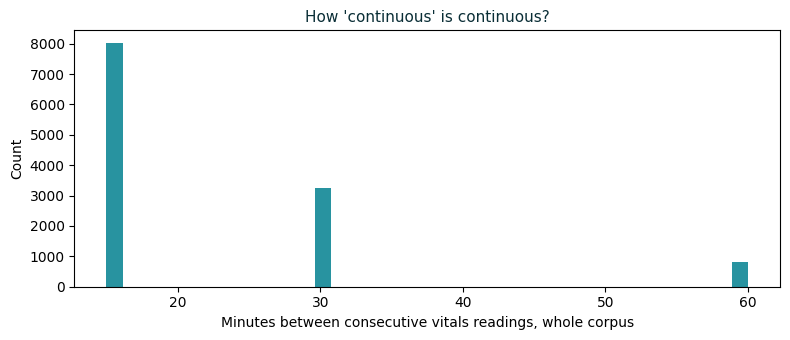

Median gap: 15 minutes. This is the fastest-moving stream we have, by a wide margin.


In [53]:
gaps = (vitals.sort_values(["subject_id","charttime"])
        .groupby("subject_id")["charttime"].diff().dt.total_seconds() / 60).dropna()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(gaps, bins=40, color=TEAL, alpha=0.85)
ax.set_xlabel("Minutes between consecutive vitals readings, whole corpus")
ax.set_ylabel("Count")
ax.set_title("How 'continuous' is continuous?", fontsize=11, color=DARK)
fig.tight_layout()
plt.show()
print(f"Median gap: {gaps.median():.0f} minutes. This is the fastest-moving stream we have, by a wide margin.")

## The intermittent stream: labs

**Real-world source:** a very different pipeline. A nurse or phlebotomist draws blood, it's labeled and sent (physically, often by pneumatic tube or courier) to the lab, run on an analyzer, checked, and resulted back into the system. That's several real-world steps, each taking real time, between "sample taken" and "result available."

Two different timestamps exist for a reason: `charttime` is when the sample was drawn, `storetime` is when the result was actually available to read.

In [54]:
labs = pd.read_csv(f"{DATA_DIR}/data/synthetic_labs_intermittent.csv", parse_dates=["charttime","storetime"])
labs.head(8)

,subject_id,hadm_id,specimen_id,charttime,storetime,label,value,valueuom,flag
0,90000001,92000001,1,2024-09-17 14:31:00,2024-09-17 20:04:00,Troponin,0.01,ng/mL,normal
1,90000001,92000001,1,2024-09-17 14:31:00,2024-09-17 20:04:00,WBC,10.77,K/uL,normal
2,90000001,92000001,1,2024-09-17 14:31:00,2024-09-17 20:04:00,Creatinine,0.74,mg/dL,normal
3,90000001,92000001,1,2024-09-17 14:31:00,2024-09-17 20:04:00,Lactate,0.83,mmol/L,normal
4,90000002,92000002,2,2025-09-18 15:39:00,2025-09-18 17:42:00,Troponin,0.00,ng/mL,normal
5,90000002,92000002,2,2025-09-18 15:39:00,2025-09-18 17:42:00,WBC,6.44,K/uL,normal
6,90000002,92000002,2,2025-09-18 15:39:00,2025-09-18 17:42:00,Lactate,0.98,mmol/L,normal
7,90000002,92000002,2,2025-09-18 15:39:00,2025-09-18 17:42:00,Potassium,3.64,mEq/L,normal


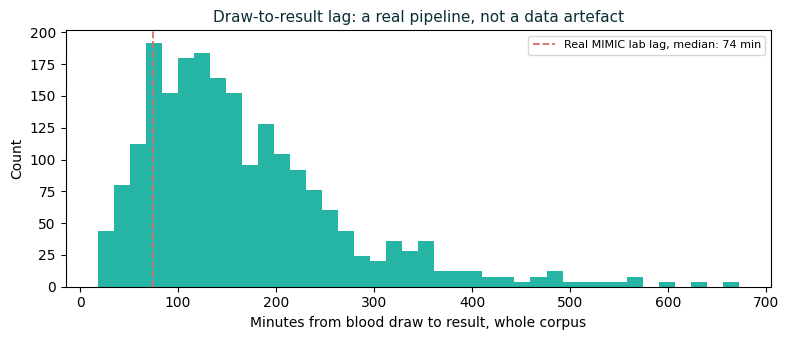

Our synthetic median: 145 minutes, calibrated against the real figure above.


In [55]:
lab_lag = (labs.storetime - labs.charttime).dt.total_seconds() / 60

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(lab_lag, bins=40, color=SEAFOAM, alpha=0.85)
ax.axvline(74, color=CORAL, linestyle="--", linewidth=1.3, label="Real MIMIC lab lag, median: 74 min")
ax.set_xlabel("Minutes from blood draw to result, whole corpus")
ax.set_ylabel("Count")
ax.legend(fontsize=8)
ax.set_title("Draw-to-result lag: a real pipeline, not a data artefact", fontsize=11, color=DARK)
fig.tight_layout()
plt.show()
print(f"Our synthetic median: {lab_lag.median():.0f} minutes, calibrated against the real figure above.")

## The delayed narrative stream: notes

**Real-world source:** people, writing at whatever moment their workflow allows, not at the moment something happens. A clinician mid-round, a nurse at handoff, a family member visiting after work. Every note has two timestamps for the same reason labs do, `event_charttime` (what it's about) and `storetime` (when it was actually written).

This is the stream where entanglement is worst, because unlike a monitor or a lab analyzer, a person's writing schedule has nothing to do with the patient's clock at all.

In [56]:
notes = pd.read_csv(f"{DATA_DIR}/data/synthetic_notes.csv", parse_dates=["event_charttime","storetime"])
notes["lag_hours"] = (notes.storetime - notes.event_charttime).dt.total_seconds() / 3600
notes[["note_type","author_type","event_charttime","storetime","lag_hours"]].head(8)

,note_type,author_type,event_charttime,storetime,lag_hours
0,admission,clinician,2024-09-17 10:43:00,2024-09-17 19:40:00,8.950000
1,routine_stable,clinician,2024-09-17 21:33:00,2024-09-18 05:17:00,7.733333
2,ecg_interpretation,clinician,2024-09-17 13:58:00,2024-09-18 07:33:00,17.583333
3,discharge,clinician,2024-09-18 03:04:00,2024-09-18 16:58:00,13.900000
4,admission,clinician,2025-09-17 22:20:00,2025-09-18 02:49:00,4.483333
5,routine_stable,clinician,2025-09-18 19:36:00,2025-09-18 22:09:00,2.550000
6,discharge,clinician,2025-09-21 17:52:00,2025-09-22 01:25:00,7.550000
7,admission,clinician,2024-04-01 09:37:00,2024-04-01 13:57:00,4.333333


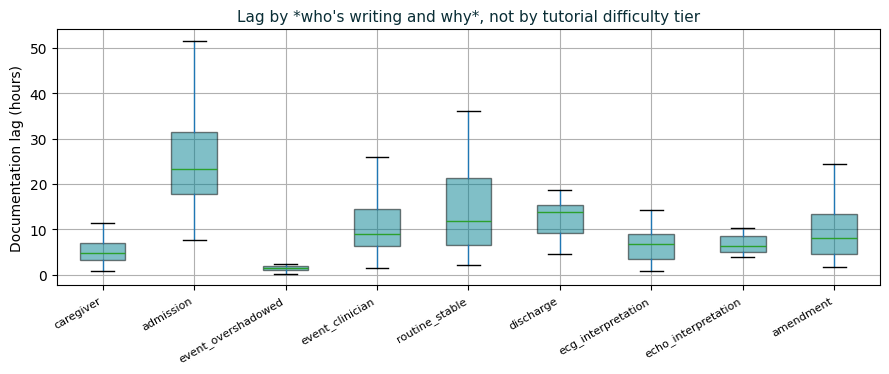

In [57]:
order = notes.groupby("note_type")["lag_hours"].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 4))
notes.boxplot(column="lag_hours", by="note_type", ax=ax, positions=range(len(order)),
              patch_artist=True, showfliers=False,
              boxprops=dict(facecolor=TEAL, alpha=0.5))
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Documentation lag (hours)")
ax.set_xlabel("")
ax.set_title("Lag by *who's writing and why*, not by tutorial difficulty tier", fontsize=11, color=DARK)
plt.suptitle("")
fig.tight_layout()
plt.show()

Compare caregiver notes to overshadowed clinician notes here. This isn't about which tier we assigned a patient to (that's Block 1's lens), it's about the fact that *different kinds of authors, for structural reasons, document at different speeds.* A family member says something the moment they notice it. A clinical note that gets filed under an existing diagnosis takes the longest of all, because nobody was in a hurry to write it.

## Structure hiding inside the narrative: medication mentions

**Real-world source:** medications are ordered in a pharmacy system and administered per a nursing record, but the *clinical reasoning* about them, why this drug, at this dose, for this reason, usually only exists as a sentence buried in free text, and it shows up differently depending on where in the stay you are: an admission note says a medication is being *started*, a routine note says it's being *continued*, a discharge note lists it as something to *keep taking*. Hospitals don't get any of this pre-extracted, someone (or something) has to pull it out.

In [58]:
notes = pd.read_csv(f"{DATA_DIR}/data/synthetic_notes.csv", parse_dates=["event_charttime","storetime"])
med_labels = pd.read_csv(f"{DATA_DIR}/data/synthetic_medication_labels.csv")

med_labels.head(8)

,subject_id,note_id,Start Position,End Position,Annotation,Group,Text
0,90000001,90000001-N2,205,214,MEDICATION,1_0001N2,Lopressor
1,90000001,90000001-N2,215,219,DOSAGE,1_0001N2,25mg
2,90000001,90000001-N2,220,222,MODE,1_0001N2,PO
3,90000001,90000001-N2,223,226,FREQUENCY,1_0001N2,BID
4,90000001,90000001-N2,231,243,REASON,1_0001N2,rate control
5,90000001,90000001-N3,175,180,MEDICATION,1_0001N3,Lasix
6,90000001,90000001-N3,181,185,DOSAGE,1_0001N3,40mg
7,90000001,90000001-N3,186,188,MODE,1_0001N3,IV


That `Text` column is the point, this file is readable on its own now: for every labeled span you can see exactly which word or phrase it refers to, without cross-referencing anything. `Start Position` / `End Position` are character offsets into the note's `text` field, `note.text[start:end]` always recovers exactly what's in `Text`.

One worked example, in full, so you can see how a mention actually reads inside real clinical narrative rather than as a table of numbers.

In [59]:
example_note_id = med_labels.note_id.unique()[0]  # change the index to see a different note
example_text = notes[notes.note_id == example_note_id].text.iloc[0]
example_spans = med_labels[med_labels.note_id == example_note_id]

print(example_text)
print()
for _, row in example_spans.iterrows():
    print(f"  {row.Annotation:10s} -> \u201c{row.Text}\u201d  (chars {row['Start Position']}\u2013{row['End Position']})")

Overnight course unremarkable. Vitals within patient's usual range. Continue monitoring. Input and output balanced over the last shift. Overnight vitals within the patient's acceptable range. Continues on Lopressor 25mg PO BID for rate control, tolerating well. Pain well controlled on current regimen.

  MEDICATION -> “Lopressor”  (chars 205–214)
  DOSAGE     -> “25mg”  (chars 215–219)
  MODE       -> “PO”  (chars 220–222)
  FREQUENCY  -> “BID”  (chars 223–226)
  REASON     -> “rate control”  (chars 231–243)


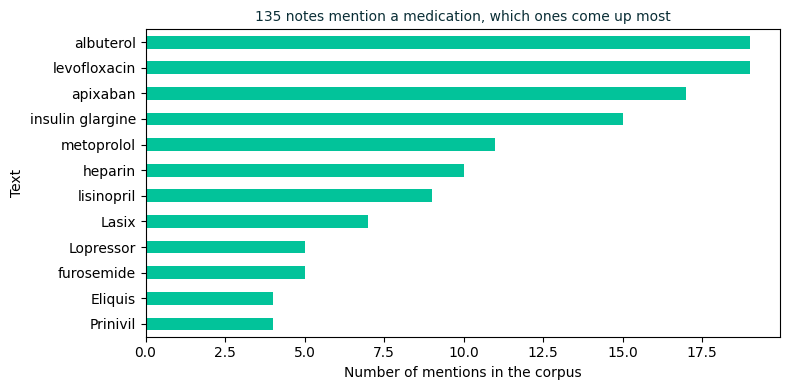

In [60]:
fig, ax = plt.subplots(figsize=(8, 4))
med_labels[med_labels.Annotation == "MEDICATION"].Text.value_counts().sort_values().plot(
    kind="barh", ax=ax, color=MINT)
ax.set_xlabel("Number of mentions in the corpus")
ax.set_title(f"{med_labels.note_id.nunique()} notes mention a medication, which ones come up most",
             fontsize=10, color=DARK)
fig.tight_layout()
plt.show()

## Try it yourself: dictionary-based extraction

You've seen *where* a medication mention lives in a note. Now let's try to *find* one ourselves, the way a real system would before anyone had hand-labeled anything.

**Real-world source:** real EHR systems don't get medication names pre-extracted either. One classic first approach is a **formulary lookup**: a reference dictionary of known drug names, checked against free text. Real hospitals represent this kind of reference data using **HL7 FHIR** (the modern healthcare interoperability standard; Fast Healthcare Interoperability Resources) `Medication` resources, coded against **RxNorm**, a terminology system built specifically to link one drug's many names, brand, generic, abbreviated, together under one canonical concept. `medication_formulary.json` below is a simplified version of exactly that.

In [61]:
import json

formulary = json.load(open(f"{DATA_DIR}/data/medication_formulary.json"))
print(formulary["description"])
print()
print(json.dumps(formulary["medications"][0], indent=2))

Simplified, FHIR-inspired medication reference for this tutorial's synthetic corpus. Real EHR systems solve the brand/generic naming problem with RxNorm-coded FHIR Medication resources; this file mirrors that structure at a scale appropriate for a three-hour tutorial.

{
  "formulary_id": "MED-001",
  "generic_name": "metoprolol",
  "known_synonyms": [],
  "typical_dose": "25mg",
  "typical_mode": "PO",
  "typical_frequency": "BID",
  "common_indications": [
    "rate control",
    "hypertension"
  ]
}


Notice `known_synonyms` is empty, for every entry. That's not an oversight, it's the honest starting state of most reference dictionaries: someone has to go find the gaps before they can be filled in.

Let's search every note for any of these generic names, and see how we do against the gold-standard labels you already met.

In [62]:
generic_names = [m["generic_name"] for m in formulary["medications"]]
generic_names

['metoprolol',
 'furosemide',
 'heparin',
 'insulin glargine',
 'levofloxacin',
 'albuterol',
 'apixaban',
 'lisinopril']

In [63]:
def find_medications(text, dictionary_terms):
    '''Naive dictionary search: does any known term appear in this text?'''
    text_lower = text.lower()
    return [term for term in dictionary_terms if term.lower() in text_lower]

In [64]:
notes_search = notes.copy()
notes_search["found_meds"] = notes_search.text.apply(lambda t: find_medications(t, generic_names))

gold_medication_notes = set(med_labels[med_labels.Annotation == "MEDICATION"].note_id)
found_notes = set(notes_search[notes_search.found_meds.map(len) > 0].note_id)

print(f"Gold standard: {len(gold_medication_notes)} notes actually contain a medication mention.")
print(f"Our naive dictionary search found: {len(found_notes)}.")
print(f"Missed: {len(gold_medication_notes - found_notes)}.")

Gold standard: 125 notes actually contain a medication mention.
Our naive dictionary search found: 105.
Missed: 20.


Not a perfect score. Let's look at exactly what we missed, using the real text, not just the count.

In [65]:
missed = gold_medication_notes - found_notes
for nid in list(missed)[:3]:
    actual_text = notes[notes.note_id == nid].text.iloc[0]
    gold_term = med_labels[(med_labels.note_id == nid) & (med_labels.Annotation == "MEDICATION")].Text.iloc[0]
    print(f"[{nid}]  gold label says the medication is \u201c{gold_term}\u201d")
    print(actual_text)
    print()

[90000043-N172]  gold label says the medication is “Eliquis”
Overnight course unremarkable. Vitals within patient's usual range. Continue monitoring. Pain well controlled on current regimen. Family updated on plan of care at bedside. Home medication Eliquis (5mg, PO, BID) continued for anticoagulation. Mobility and appetite both improving steadily. Overnight vitals within the patient's acceptable range.

[90000041-N160]  gold label says the medication is “Lopressor”
Patient's condition improved / stabilized over the admission. Discharged with follow-up plan in place. Patient verbalizes understanding of the discharge plan. Return precautions reviewed with patient. Discharge medications include Lopressor 25mg PO BID for hypertension. Patient ambulating independently prior to discharge. Transportation home arranged with family.

[90000074-N296]  gold label says the medication is “Lopressor”
Patient's condition improved / stabilized over the admission. Discharged with follow-up plan in pla

Every single miss is the same kind of thing: the note used a **brand name**, Lasix instead of furosemide, Lopressor instead of metoprolol, and so on. Our dictionary wasn't wrong, it was just incomplete, exactly the gap a real formulary team spends real time closing.

This is the actual fix, not a different algorithm, a **better-curated concept**: teach the dictionary that these names refer to the same drug, the same thing RxNorm does for the entire real world's medication vocabulary.

In [66]:
brand_names_discovered = {
    "metoprolol": "Lopressor",
    "furosemide": "Lasix",
    "lisinopril": "Prinivil",
    "apixaban": "Eliquis",
}

In [67]:
for med in formulary["medications"]:
    if med["generic_name"] in brand_names_discovered:
        med["known_synonyms"].append(brand_names_discovered[med["generic_name"]])

all_terms = generic_names + [syn for m in formulary["medications"] for syn in m["known_synonyms"]]
print(f"Expanded dictionary: {len(all_terms)} terms (started with {len(generic_names)})")

Expanded dictionary: 12 terms (started with 8)


In [68]:
notes_search["found_meds_v2"] = notes_search.text.apply(lambda t: find_medications(t, all_terms))
found_notes_v2 = set(notes_search[notes_search.found_meds_v2.map(len) > 0].note_id)

print(f"With the expanded dictionary: found {len(found_notes_v2)} / {len(gold_medication_notes)}")
print(f"Still missing: {len(gold_medication_notes - found_notes_v2)}")

With the expanded dictionary: found 125 / 125
Still missing: 0


From an incomplete dictionary to a complete one, by going and looking at exactly what it missed and why. That's the whole discipline in miniature: a naive lookup isn't wrong to start with, it's just never finished, and real document engineering work is finding out where, specifically, it still fails.

## One more thing about notes: some of them get corrected

Every note you've looked at so far had one flaw: it arrived late. Here's a second, different flaw, rarer, but real: sometimes what arrived was **wrong**, a transcribed dose, a misheard drug name, and someone had to go back and fix it.

This isn't a ninth source, it's the same narrative stream you've already met, doing something documentation lag alone doesn't explain. A note that's late is still, eventually, correct. A note that's been amended means the record disagreed with itself for a while, and you have to know *when you're asking* to know which version was true.

In [69]:
notes = pd.read_csv(f"{DATA_DIR}/data/synthetic_notes.csv", parse_dates=["event_charttime","storetime"])
amendments = notes[notes.note_type == "amendment"]
print(f"{len(amendments)} amendment(s) across the corpus, out of {len(notes)} notes total.")

17 amendment(s) across the corpus, out of 385 notes total.


In [71]:
amendments = notes[notes.note_type == "amendment"].copy()
originals = notes.set_index("note_id")

amendments["original_charted"] = amendments.amends_note_id.map(originals.storetime)
amendments["lag_hours"] = (amendments.storetime - amendments.original_charted).dt.total_seconds() / 3600
amendments["n_amendments_this_patient"] = amendments.groupby("subject_id")["subject_id"].transform("count")

summary = amendments[["subject_id", "n_amendments_this_patient", "note_id", "amendment_reason", "lag_hours"]]
summary = summary.sort_values(["subject_id", "note_id"]).round({"lag_hours": 1})
summary

,subject_id,n_amendments_this_patient,note_id,amendment_reason,lag_hours
15,90000004,1,90000004-N14-AMEND1,"wrong drug charted, corrected to actual order",14.5
43,90000009,1,90000009-N33-AMEND1,dosage transcription error,16.4
159,90000033,1,90000033-N125-AMEND1,dosage transcription error,7.4
179,90000037,1,90000037-N141-AMEND1,dosage transcription error,15.1
228,90000046,1,90000046-N186-AMEND1,dosage transcription error,26.5
259,90000052,1,90000052-N210-AMEND1,"wrong drug charted, corrected to actual order",25.0
267,90000054,2,90000054-N217-AMEND1,"wrong drug charted, corrected to actual order",8.3
271,90000054,2,90000054-N218-AMEND1,dosage transcription error,17.5
278,90000056,1,90000056-N224-AMEND1,dosage transcription error,24.2
285,90000057,1,90000057-N228-AMEND1,dosage transcription error,27.7


In [76]:
example = amendments.iloc[1] ## try changing the number in [] to get different amendments
original = notes[notes.note_id == example.amends_note_id].iloc[0]
print(f"\nOriginal note {original.note_id}, charted {original.storetime}:")
print(f"  {original.text}")
print(f"\nAmendment {example.note_id}, charted {example.storetime}  ({example.amendment_reason}):")
print(f"  {example.text}")


Original note 90000009-N33, charted 2025-09-25 21:23:00:
  Overnight course unremarkable. Vitals within patient's usual range. Continue monitoring. Physical therapy assessment completed today. Home medication metoprolol (25mg, PO, BID) continued for rate control. Sleeping well overnight per patient report.

Amendment 90000009-N33-AMEND1, charted 2025-09-26 13:48:00  (dosage transcription error):
  ADDENDUM to note 90000009-N33: dosage was charted incorrectly. Corrected dosage: 12.5mg (previously 25mg).


Notice the amendment's own "event" time: it's copied straight from the note it corrects, not set to the moment someone caught the error. The clinical event didn't move. Only the documentation of it did, twice. Block 1's capstone builds a document that actually knows the difference.

## A third real-world workflow: ECG and echo

**Real-world source:** three separate people, three separate systems. A physician orders the study. A technician performs it, and a machine or the tech generates a preliminary technical report. Later, sometimes much later, a cardiologist or the attending actually reviews it and charts a clinical interpretation. Three timestamps, three different actors, in every single study.

In [77]:
ecg = pd.read_csv(f"{DATA_DIR}/data/synthetic_ecg_events.csv", parse_dates=["ecg_time","report_time"])
echo = pd.read_csv(f"{DATA_DIR}/data/synthetic_echo_events.csv", parse_dates=["echo_time","report_time"])
display(ecg.head(8))
display(echo.head(8))

,ecg_id,subject_id,hadm_id,ecg_time,report_time,finding,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
0,90000001-ECG1,90000001,92000001,2024-09-17 13:58:00,2024-09-17 14:26:00,"Sinus rhythm, otherwise normal ECG",731.0,37.0,120.0,169.0,257.0,476.0,63.0,64.0,42.0
1,90000003-ECG2,90000003,92000003,2024-04-01 10:35:00,2024-04-01 10:56:00,Left ventricular hypertrophy,596.0,46.0,118.0,165.0,254.0,479.0,81.0,-29.0,51.0
2,90000004-ECG3,90000004,92000004,2024-04-08 00:57:00,2024-04-08 01:21:00,Sinus rhythm with occasional ectopy,671.0,35.0,139.0,183.0,248.0,446.0,72.0,47.0,55.0
3,90000005-ECG4,90000005,92000005,2024-11-26 10:58:00,2024-11-26 11:19:00,"Sinus rhythm, otherwise normal ECG",674.0,45.0,135.0,156.0,256.0,484.0,57.0,51.0,49.0
4,90000006-ECG5,90000006,92000006,2025-08-20 18:03:00,2025-08-20 18:35:00,Sinus rhythm with occasional ectopy,671.0,40.0,145.0,163.0,233.0,478.0,53.0,49.0,38.0
5,90000009-ECG6,90000009,92000009,2025-09-24 08:25:00,2025-09-24 08:57:00,Normal sinus rhythm,567.0,36.0,100.0,172.0,233.0,494.0,50.0,40.0,69.0
6,90000009-ECG7,90000009,92000009,2025-09-24 20:12:00,2025-09-24 20:36:00,Left ventricular hypertrophy,525.0,45.0,132.0,163.0,256.0,492.0,56.0,-24.0,41.0
7,90000011-ECG8,90000011,92000011,2024-08-31 09:59:00,2024-08-31 10:29:00,"Sinus rhythm, otherwise normal ECG",636.0,42.0,130.0,164.0,242.0,465.0,34.0,74.0,50.0


,echo_id,subject_id,hadm_id,echo_time,report_time,lvef_percent,wall_motion_abnormality,valve_regurgitation,pericardial_effusion,finding
0,90000006-ECHO1,90000006,92000006,2025-08-20 18:53:00,2025-08-20 21:27:00,60.0,N,none,N,"Preserved LVEF, no significant valvular disease."
1,90000007-ECHO2,90000007,92000007,2024-01-17 16:26:00,2024-01-18 00:54:00,33.0,Y,moderate,N,"Moderate mitral regurgitation, preserved LVEF."
2,90000012-ECHO3,90000012,92000012,2024-08-21 03:26:00,2024-08-21 06:35:00,61.0,N,mild,N,Normal biventricular size and systolic function.
3,90000014-ECHO4,90000014,92000014,2024-12-27 03:24:00,2024-12-27 05:14:00,67.0,N,trace,N,"Preserved LVEF, no significant valvular disease."
4,90000015-ECHO5,90000015,92000015,2025-04-09 01:47:00,2025-04-09 03:21:00,40.0,Y,trace,Y,Reduced LVEF with global hypokinesis.
5,90000016-ECHO6,90000016,92000016,2025-09-05 01:02:00,2025-09-05 07:12:00,65.0,N,trace,N,Normal biventricular size and systolic function.
6,90000018-ECHO7,90000018,92000018,2025-10-09 18:48:00,2025-10-09 20:26:00,60.0,N,none,N,Normal biventricular size and systolic function.
7,90000019-ECHO8,90000019,92000019,2024-03-18 09:43:00,2024-03-18 10:51:00,34.0,Y,mild,N,"Moderate mitral regurgitation, preserved LVEF."


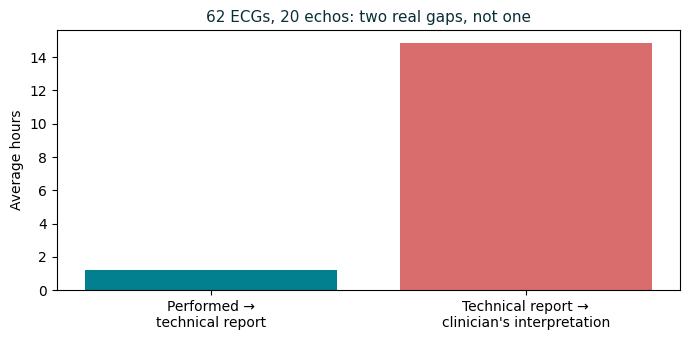

In [78]:
interp = notes[notes.note_type.isin(["ecg_interpretation","echo_interpretation"])].merge(
    pd.concat([ecg.assign(kind="ecg")[["subject_id","ecg_id","kind"]].rename(columns={"ecg_id":"related_event_id"}),
               echo.assign(kind="echo")[["subject_id","echo_id","kind"]].rename(columns={"echo_id":"related_event_id"})]),
    on=["subject_id","related_event_id"])

stage1 = pd.concat([
    (ecg.report_time - ecg.ecg_time).dt.total_seconds()/3600,
    (echo.report_time - echo.echo_time).dt.total_seconds()/3600,
])
stage1_labels = ["performed \u2192 technical report"] * len(stage1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(["Performed \u2192\ntechnical report", "Technical report \u2192\nclinician's interpretation"],
       [stage1.mean(), interp.documentation_lag_hours.mean() if "documentation_lag_hours" in interp.columns
        else (interp.storetime - interp.event_charttime).dt.total_seconds().mean()/3600],
       color=[TEAL, CORAL])
ax.set_ylabel("Average hours")
ax.set_title(f"{len(ecg)} ECGs, {len(echo)} echos: two real gaps, not one", fontsize=11, color=DARK)
fig.tight_layout()
plt.show()

The gap from "performed" to "technical report" is short, that's mostly machine time. The gap from "technical report exists" to "a clinician actually charted what it means" is the one that matters clinically, and it's the one a naive system would never think to look for, because the technical report already looks like "the data arrived.\"

## The hospital as a process: the event log

**Real-world source:** every action in a hospital stay, admission, a vitals check, a lab drawn, a note filed, discharge, leaves a timestamped trace somewhere. Lay all of those traces end to end for one stay and you get something closer to a business process log than a medical record. This is exactly the abstraction process-mining researchers use, and it's exactly the shape that will let us generalize this tutorial's methods to legal and financial records in Block 3.

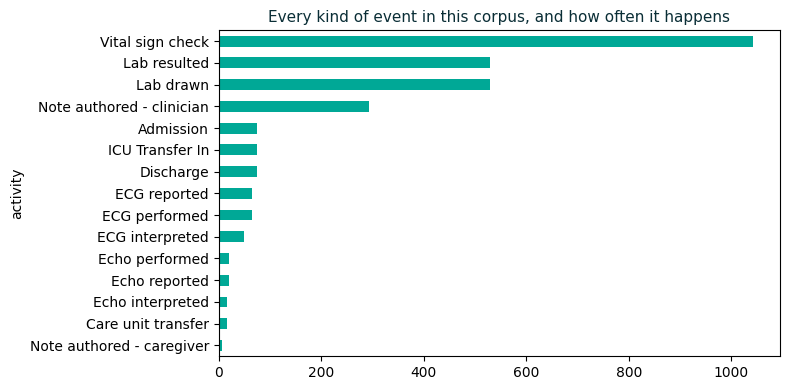

In [79]:
event_log = pd.read_csv(f"{DATA_DIR}/data/synthetic_event_log.csv")

fig, ax = plt.subplots(figsize=(8, 4))
event_log.activity.value_counts().sort_values().plot(kind="barh", ax=ax, color=SEAFOAM)
ax.set_title("Every kind of event in this corpus, and how often it happens", fontsize=11, color=DARK)
fig.tight_layout()
plt.show()

## So none of this lives in one place. That's the actual problem.

Look back at what you've just seen: a registration system, a bedside monitor, a lab analyzer, a nurse, a family member, a pharmacy system, an ECG machine, a cardiologist, a hospital's operational logs. **Eight different real-world systems and people, each with their own format, their own timing, their own idea of what counts as "done."**

Nobody designed this to be hard to analyze together. It's hard because it was never designed to be analyzed together at all, each piece was built to solve its own local problem. Turning that into something a person, or a model, can reason about *as one coherent record* is not a data science problem first. It's a **document engineering** problem: how do you structure, represent, and unify evidence that was never structured, represented, or unified to begin with?

That's what the `document_schema.json` you'll see in Block 1 actually solves. Here's just its shape, not the full rendered content, that's Block 1's job.

In [80]:
with open(f"{DATA_DIR}/data/document_schema.json") as f:
    schema = json.load(f)

def print_shape(props, indent=0):
    for key, val in props.items():
        print("  " * indent + f"- {key}")
        if isinstance(val, dict) and "properties" in val:
            print_shape(val["properties"], indent + 1)

print_shape(schema["properties"])

- schema_version
- generated_by
- hadm_id
- subject_id
- admission
  - admittime
  - dischtime
  - age
  - gender
  - careunit
  - admit_reason
  - comorbidities
  - has_cardiac_history
- complexity_context
  - hospital_complexity_tier
  - entanglement_tier
  - population_context
  - socioeconomic_context
- evidence_streams
  - continuous_signal
    - provenance
    - n_readings
    - readings
  - intermittent_measurements
    - provenance
    - n_draws
    - draws
  - delayed_narrative
    - provenance
    - notes
  - diagnostic_studies
    - ecg
    - echo


## Prove it, don't just claim it

Everything you've looked at so far in this notebook is *our own* clean CSV format. That's a fair question to ask about: does the "eight different real-world systems" story actually hold up against something a real hospital system would produce, not something we made tidy on purpose?

Two real formats, for real: **HL7 FHIR** (the modern EHR export standard) and **MUSE XML** (a real cardiology ECG system's export format, GE Healthcare's, specifically). Let's look at the raw files, then watch them get unified.

In [81]:
with open(f"{DATA_DIR}/data/XML_JSON/muse_xml/MUSE_90000001_ECG1.xml") as f:
    muse_raw = f.read()

# the first ~40 lines: patient demographics, test metadata, and the start of
# the measurements block, before the waveform data even begins
print("\n".join(muse_raw.splitlines()[:40]))

<?xml version="1.0" encoding="ISO-8859-1"?>
<!DOCTYPE RestingECG SYSTEM "restecg.dtd"[]>
<RestingECG>
   <MuseInfo>
      <MuseVersion>SYNTHETIC-TUTORIAL-1.0</MuseVersion>
   </MuseInfo>
   <PatientDemographics>
      <PatientID>90000001</PatientID>
      <PatientAge>35</PatientAge>
      <AgeUnits>YEARS</AgeUnits>
      <DateofBirth>01/01/1989</DateofBirth>
      <Gender>MALE</Gender>
      <Race>UNSPECIFIED</Race>
      <PatientLastName>SYNTHETIC</PatientLastName>
      <PatientFirstName>PT90000001</PatientFirstName>
   </PatientDemographics>
   <TestDemographics>
      <DataType>RESTING</DataType>
      <SiteName>DocEng26-Tutorial-Synthetic</SiteName>
      <AcquisitionDevice>SIMULATED</AcquisitionDevice>
      <Status>CONFIRMED</Status>
      <Priority>NORMAL</Priority>
      <LocationName>CVICU</LocationName>
      <AcquisitionTime>13:58:00</AcquisitionTime>
      <AcquisitionDate>09-17-2024</AcquisitionDate>
      <OverreaderLastName>Synthetic</OverreaderLastName>
      <Overread

That `<WaveFormData>` section further down is base64-encoded binary, thousands of raw amplitude samples, real ECG waveform data, not a text description of one. Real cardiology systems export exactly this shape of file, DTD reference and all.

In [82]:
from parse_muse_xml import parse_muse_xml

parsed = parse_muse_xml(f"{DATA_DIR}/data/XML_JSON/muse_xml/MUSE_90000001_ECG1.xml")
for k, v in parsed.items():
    print(f"{k}: {v}")

subject_id: 90000001
finding: Sinus rhythm, otherwise normal ECG
rr_interval: 732
p_onset: 37.0
p_end: 120.0
qrs_onset: 169.0
qrs_end: 257.0
t_end: 476.0
p_axis: 63.0
qrs_axis: 64.0
t_axis: 42.0
decoded_waveform_peak_to_peak_uv: 1366.4
provenance: {'format': 'MUSE XML (GE Healthcare RestingECG)', 'source_system': 'Cardiology ECG acquisition system', 'raw_source_file': '/content/doceng26-pulse-and-paper//data/XML_JSON/muse_xml/MUSE_90000001_ECG1.xml'}


`decoded_waveform_peak_to_peak_uv` isn't read from a metadata field, it comes from actually decoding the base64 waveform samples back to microvolts and measuring their range. That's genuine parsing, the same thing a real ingestion pipeline has to do.

Let's not stop at a single number. Here's the actual trace.

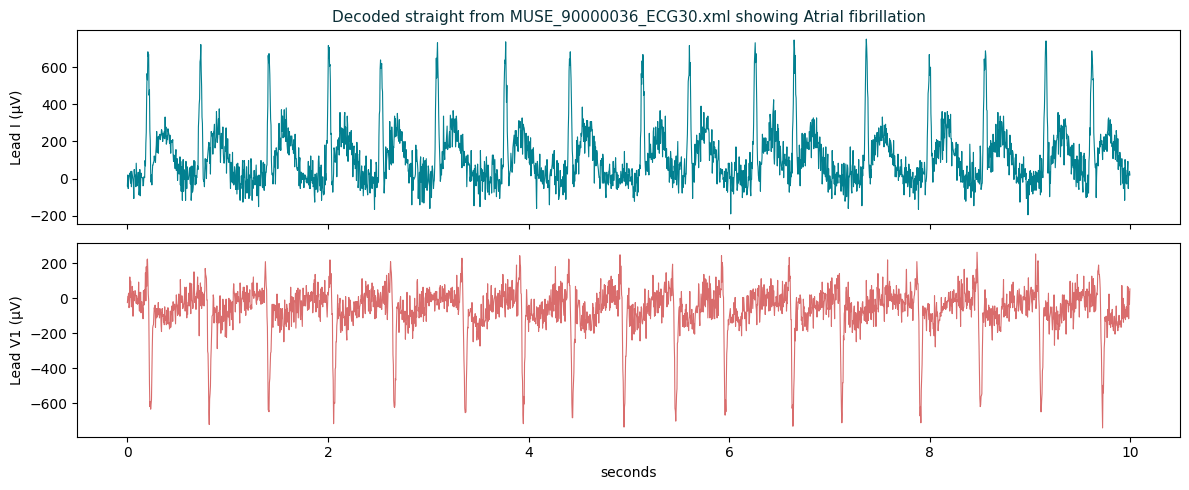

In [83]:
from parse_muse_xml import decode_all_leads
import numpy as np

leads, sample_rate_hz = decode_all_leads(f"{DATA_DIR}/data/XML_JSON/muse_xml/MUSE_90000036_ECG30.xml", waveform_type="Rhythm")
t = np.arange(len(leads["I"])) / sample_rate_hz

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, leads["I"], color=TEAL, linewidth=0.8)
axes[0].set_ylabel("Lead I (\u00b5V)")
axes[0].set_title("Decoded straight from MUSE_90000036_ECG30.xml showing Atrial fibrillation", fontsize=11, color=DARK)
axes[1].plot(t, leads["V1"], color=CORAL, linewidth=0.8)
axes[1].set_ylabel("Lead V1 (\u00b5V)")
axes[1].set_xlabel("seconds")
fig.tight_layout()
plt.show()

Ten real seconds, two of the eight leads actually stored in the file, decoded from nothing but base64 bytes and a DTD-shaped XML document. Look at the spacing between the tall spikes, it's irregular, on purpose: this file's diagnosis says atrial fibrillation, and the waveform actually behaves like it, not just the text label next to it.

Now the other real format. Modern EHRs export structured data as FHIR Bundles, JSON, coded against standard terminologies (LOINC for vitals and labs, in this example).

Other resource types worth trying instead of `"Observation"`, same pattern, just swap the string:

- **`"Patient"`** — the demographic anchor. Just `id`, `gender`, `birthDate`. The simplest resource in the bundle.
- **`"Encounter"`** — the admission itself: `status`, `class` (inpatient/etc.), `period` (admit/discharge), `reasonCode`. The FHIR equivalent of a row in `synthetic_patients.csv`.
- **`"Condition"`** — a diagnosis or comorbidity, coded rather than free text, linked back to both the patient and the encounter.
- **`"MedicationStatement"`** — the FHIR analog of the medication spans you pulled out of raw text earlier, but coded from the start: `medicationCodeableConcept`, `dosage`, `reasonCode`. Worth comparing side by side with the character-span version, same information, two completely different representations.
- **`"DocumentReference"`** — this is where the actual clinical notes live in FHIR. Print one raw and you'll get garbled base64 instead of readable text, that's not a bug, it's why `parse_fhir_bundle.py` exists.

`Observation` covers both vitals and labs in this bundle, so if you want a lab specifically, you'll need to filter further, most likely on the resource's `code` field (LOINC-coded).

In [84]:
with open(f"{DATA_DIR}/data/XML_JSON/fhir_export/fhir_bundle_90000017.json") as f:
    fhir_raw = json.load(f)

# one Observation resource, exactly as an EHR would hand it to you
one_obs = next(e["resource"] for e in fhir_raw["entry"] if e["resource"]["resourceType"] == "Observation")
print(json.dumps(one_obs, indent=2))

{
  "resourceType": "Observation",
  "id": "90000017-vit-3988-heartrate",
  "status": "final",
  "category": [
    {
      "coding": [
        {
          "system": "http://terminology.hl7.org/CodeSystem/observation-category",
          "code": "vital-signs"
        }
      ]
    }
  ],
  "code": {
    "coding": [
      {
        "system": "http://loinc.org",
        "code": "8867-4",
        "display": "Heart rate"
      }
    ]
  },
  "subject": {
    "reference": "Patient/90000017"
  },
  "encounter": {
    "reference": "Encounter/92000017"
  },
  "effectiveDateTime": "2025-05-01T13:13:00+00:00",
  "valueQuantity": {
    "value": 83.9,
    "unit": "beats/minute",
    "system": "http://unitsofmeasure.org",
    "code": "/min"
  }
}


In [85]:
one_obs = next(e["resource"] for e in fhir_raw["entry"] if e["resource"]["resourceType"] == "Patient")
print(json.dumps(one_obs, indent=2))

{
  "resourceType": "Patient",
  "id": "90000017",
  "gender": "female",
  "birthDate": "1955-01-01"
}


In [86]:
from parse_fhir_bundle import parse_fhir_bundle

parsed_fhir = parse_fhir_bundle(f"{DATA_DIR}/data/XML_JSON/fhir_export/fhir_bundle_90000017.json")
print(f"Parsed: {len(parsed_fhir['vitals'])} vitals, {len(parsed_fhir['labs'])} labs, "
      f"{len(parsed_fhir['notes'])} notes, {len(parsed_fhir['medications'])} medications")
print()
print("one parsed vitals reading:", parsed_fhir["vitals"][0])

Parsed: 70 vitals, 68 labs, 9 notes, 2 medications

one parsed vitals reading: {'subject_id': 90000017, 'loinc_code': '8867-4', 'label': 'Heart rate', 'charttime': '2025-05-01T13:13:00+00:00', 'value': 83.9, 'unit': 'beats/minute'}


Other things worth printing instead of `parsed_fhir["vitals"][0]`, same dict, different keys:

- **`parsed_fhir["labs"][0]`** — same shape as a vitals reading (`loinc_code`, `label`, `charttime`, `value`, `unit`), plus two extra fields vitals don't have: `storetime` (when it resulted) and `flag` (normal/abnormal), pulled from the Observation's `issued` and `interpretation` fields. Good side-by-side with a vitals reading to see exactly what "intermittent with two timestamps" looks like in FHIR terms.
- **`parsed_fhir["notes"][0]`** — the most interesting one. `note_id`, `note_type`, `author_type`, `event_charttime`, `storetime`, and `text`, the text is the actual base64 content from the raw `DocumentReference` decoded back to readable English. Print this one next to the raw `DocumentReference` resource from the previous cell, that's the before/after of parsing in one screen.
- **`parsed_fhir["medications"][0]`** — `medication`, `dosage`, `reason`, `effectiveDateTime`, pulled from `MedicationStatement`. Worth comparing to the character-span medication mentions from earlier in the notebook: same kind of fact, coded rather than extracted from free text.
- **`parsed_fhir["patient"]`** and **`parsed_fhir["encounter"]`** — not lists, just single dicts (`subject_id`/`gender`/`birthDate`, and `hadm_id`/`period`/`careunit`). The demographic and admission facts the parser pulled out along the way.
- **`parsed_fhir["provenance"]`** — `format`, `source_system`, `raw_source_file`, exactly what ends up on the document object later, generated right here at parse time, not added afterward.

Rough counts for this bundle: ~65 vitals, ~4 labs, 4 notes, 2 medications, so `labs[0]` and `medications[0]` exist but won't have many siblings to page through.

Both formats, different from each other and from our CSVs, both now sitting in plain Python dictionaries with the same shape. That's the unification step. Let's confirm it actually landed in the final documents, with honest provenance, not a label asserting it did.

In [87]:
with open(f"{DATA_DIR}/data/synthetic_documents.json") as f:
    documents = json.load(f)

# the patient whose vitals/labs/notes came from the FHIR bundle above
d = documents["92000017"]
print("continuous_signal provenance:", d["evidence_streams"]["continuous_signal"]["provenance"])
print()

# the ECG that came from the MUSE XML file above
for e in documents["92000001"]["evidence_streams"]["diagnostic_studies"]["ecg"]:
    print(f"ECG {e['ecg_id']}: provenance = {e['provenance']['format']}")

# for comparison: a patient with no raw source file, correctly falls back to CSV
print()
print("a patient with no FHIR/MUSE file available:",
      documents["92000002"]["evidence_streams"]["continuous_signal"]["provenance"]["format"])

continuous_signal provenance: {'format': 'HL7 FHIR R4 Bundle', 'source_system': 'EHR export', 'raw_source_file': './data/XML_JSON/fhir_export/fhir_bundle_90000017.json'}

ECG 90000001-ECG1: provenance = MUSE XML (GE Healthcare RestingECG)

a patient with no FHIR/MUSE file available: Tutorial CSV export


Every document in `synthetic_documents.json` can now tell you, honestly, whether it was built from a real parsed source or from our tutorial's CSV, because it actually was one or the other, not because we labeled it that way afterward. That's the difference between claiming a pipeline unifies heterogeneous formats and demonstrating one that does.

## Eight sources. One schema. That's the whole argument of this tutorial, and you've now seen the evidence for it firsthand, in the data itself, before we've written a single line of alignment code.

## What's next

Block 1 picks one patient out of this corpus and follows their story in detail: a full multi-track timeline, documentation lag computed by hand, and a real rendered document generated from everything you've just met. You now know what each track actually *is* and where it comes from. Block 1 is where you'll watch it collide.